# News Article Category Prediction

Predicting the category of a news article (lifestyle, entertainment, tech, business, world, social media) using the OnlineNewsPopularity dataset and Random Forest classifier.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported.')

All libraries imported.


## Step 1 - Loading the Dataset

In [2]:
data = pd.read_csv('OnlineNewsPopularity/OnlineNewsPopularity.csv')
print('Dataset loaded.')
print('Rows:', data.shape[0])
print('Columns:', data.shape[1])

Dataset loaded.
Rows: 39644
Columns: 61


## Step 2 - Cleaning Column Names

The column names in this dataset have extra leading spaces. We need to strip them.

In [3]:
# before cleaning
print('Before:', data.columns[:3].tolist())

data.columns = data.columns.str.strip()

# after cleaning
print('After:', data.columns[:3].tolist())

Before: ['url', ' timedelta', ' n_tokens_title']
After: ['url', 'timedelta', 'n_tokens_title']


## Step 3 - Basic Dataset Info

In [4]:
# first 5 rows
data.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [5]:
print('Shape:', data.shape)
print()
print('Columns:')
for i, col in enumerate(data.columns):
    print(f'  {i+1}. {col}')

Shape: (39644, 61)

Columns:
  1. url
  2. timedelta
  3. n_tokens_title
  4. n_tokens_content
  5. n_unique_tokens
  6. n_non_stop_words
  7. n_non_stop_unique_tokens
  8. num_hrefs
  9. num_self_hrefs
  10. num_imgs
  11. num_videos
  12. average_token_length
  13. num_keywords
  14. data_channel_is_lifestyle
  15. data_channel_is_entertainment
  16. data_channel_is_bus
  17. data_channel_is_socmed
  18. data_channel_is_tech
  19. data_channel_is_world
  20. kw_min_min
  21. kw_max_min
  22. kw_avg_min
  23. kw_min_max
  24. kw_max_max
  25. kw_avg_max
  26. kw_min_avg
  27. kw_max_avg
  28. kw_avg_avg
  29. self_reference_min_shares
  30. self_reference_max_shares
  31. self_reference_avg_sharess
  32. weekday_is_monday
  33. weekday_is_tuesday
  34. weekday_is_wednesday
  35. weekday_is_thursday
  36. weekday_is_friday
  37. weekday_is_saturday
  38. weekday_is_sunday
  39. is_weekend
  40. LDA_00
  41. LDA_01
  42. LDA_02
  43. LDA_03
  44. LDA_04
  45. global_subjectivity
  46. g

In [6]:
data.describe()

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,...,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,...,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,...,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,946.000000
50%,339.000000,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,...,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1400.000000
75%,542.000000,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,...,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000,2800.000000
max,731.000000,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


In [7]:
# check for missing values
print('Missing values:', data.isnull().sum().sum())

Missing values: 0


## Step 4 - Creating the Target Column

The dataset has 6 binary columns indicating the article category. We combine them into one column called `category`.

In [8]:
# mapping each channel column to a readable category name
channel_map = {
    'data_channel_is_lifestyle': 'lifestyle',
    'data_channel_is_entertainment': 'entertainment',
    'data_channel_is_tech': 'tech',
    'data_channel_is_bus': 'business',
    'data_channel_is_world': 'world',
    'data_channel_is_socmed': 'social media'
}

def get_category(row):
    for col, name in channel_map.items():
        if row[col] == 1:
            return name
    return None

data['category'] = data.apply(get_category, axis=1)

print('Category column created.')
print()
print(data['category'].value_counts())

Category column created.

category
world            8427
tech             7346
entertainment    7057
business         6258
social media     2323
lifestyle        2099
Name: count, dtype: int64


## Step 5 - Removing Rows with No Category

Some articles do not belong to any of the 6 channels. We drop them.

In [9]:
print('Rows before:', data.shape[0])

data = data.dropna(subset=['category'])

print('Rows after:', data.shape[0])
print('Dropped', 39644 - data.shape[0], 'rows with no category.')

Rows before: 39644
Rows after: 33510
Dropped 6134 rows with no category.


In [10]:
# category distribution
print('Category counts:')
print(data['category'].value_counts())
print()
print('Percentages:')
print(round(data['category'].value_counts(normalize=True) * 100, 1))

Category counts:
category
world            8427
tech             7346
entertainment    7057
business         6258
social media     2323
lifestyle        2099
Name: count, dtype: int64

Percentages:
category
world            25.1
tech             21.9
entertainment    21.1
business         18.7
social media      6.9
lifestyle         6.3
Name: proportion, dtype: float64


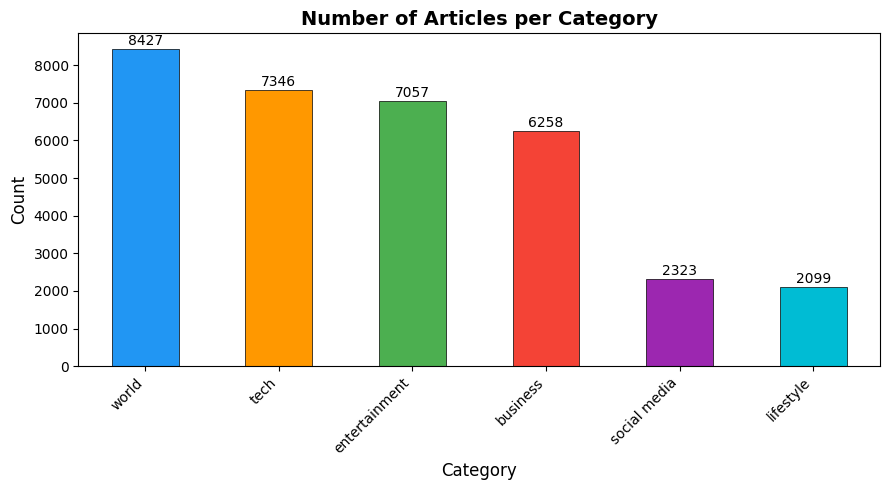

In [11]:
# bar chart of category distribution
colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336', '#9C27B0', '#00BCD4']

plt.figure(figsize=(9, 5))
ax = data['category'].value_counts().plot(kind='bar', color=colors, edgecolor='black', linewidth=0.5)
plt.title('Number of Articles per Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

# adding count labels on top of bars
for i, v in enumerate(data['category'].value_counts()):
    ax.text(i, v + 100, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Step 6 - Selecting Features

We pick 9 relevant features for our model.

In [12]:
features = [
    'n_tokens_title',
    'n_tokens_content',
    'average_token_length',
    'num_imgs',
    'num_videos',
    'kw_avg_avg',
    'global_sentiment_polarity',
    'global_subjectivity',
    'title_sentiment_polarity'
]

X = data[features]
y = data['category']

print('Features:', X.shape[1])
print('Samples:', X.shape[0])
print()
print('Selected features:')
for f in features:
    print(f'  - {f}')

Features: 9
Samples: 33510

Selected features:
  - n_tokens_title
  - n_tokens_content
  - average_token_length
  - num_imgs
  - num_videos
  - kw_avg_avg
  - global_sentiment_polarity
  - global_subjectivity
  - title_sentiment_polarity


In [13]:
X.head()

,n_tokens_title,n_tokens_content,average_token_length,num_imgs,num_videos,kw_avg_avg,global_sentiment_polarity,global_subjectivity,title_sentiment_polarity
0,12.0,219.0,4.680365,1.0,0.0,0.0,0.092562,0.521617,-0.187500
1,9.0,255.0,4.913725,1.0,0.0,0.0,0.148948,0.341246,0.000000
2,9.0,211.0,4.393365,1.0,0.0,0.0,0.323333,0.702222,0.000000
3,9.0,531.0,4.404896,1.0,0.0,0.0,0.100705,0.429850,0.000000
4,13.0,1072.0,4.682836,20.0,0.0,0.0,0.281003,0.513502,0.136364


In [14]:
# quick stats of selected features
X.describe().round(2)

,n_tokens_title,n_tokens_content,average_token_length,num_imgs,num_videos,kw_avg_avg,global_sentiment_polarity,global_subjectivity,title_sentiment_polarity
count,33510.00,33510.00,33510.00,33510.00,33510.00,33510.00,33510.00,33510.00,33510.00
mean,10.42,585.44,4.61,3.96,1.00,2890.42,0.12,0.44,0.07
std,2.13,483.84,0.65,7.73,3.65,1126.33,0.09,0.10,0.25
min,2.00,0.00,0.00,0.00,0.00,0.00,-0.38,0.00,-1.00
25%,9.00,272.00,4.49,1.00,0.00,2312.97,0.06,0.39,0.00
50%,10.00,447.00,4.67,1.00,0.00,2737.05,0.12,0.45,0.00
75%,12.00,761.00,4.85,3.00,1.00,3271.47,0.18,0.50,0.14
max,23.00,8474.00,7.70,128.00,75.00,43567.66,0.73,1.00,1.00


## Step 7 - Train-Test Split

Splitting 80% for training and 20% for testing.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])
print()
print('Train split:', round(X_train.shape[0] / X.shape[0] * 100, 1), '%')
print('Test split:', round(X_test.shape[0] / X.shape[0] * 100, 1), '%')

Training samples: 26808
Testing samples: 6702

Train split: 80.0 %
Test split: 20.0 %


## Step 8 - Feature Scaling (StandardScaler)

Standardizing the features so they all have similar ranges.

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaling done.')
print()
print('Before scaling (first row):')
print(X_train.iloc[0].values.round(3))
print()
print('After scaling (first row):')
print(X_train_scaled[0].round(3))

Scaling done.

Before scaling (first row):
[ 1.000000e+01  2.540000e+02  4.583000e+00  1.000000e+00  0.000000e+00
  3.518853e+03  1.180000e-01  4.050000e-01 -1.560000e-01]

After scaling (first row):
[-0.19  -0.679 -0.037 -0.38  -0.273  0.567 -0.021 -0.348 -0.884]


## Step 9 - Training the Model

Using RandomForestClassifier with 200 trees. We set `class_weight='balanced'` because some categories have more articles than others.

In [17]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

print('Model trained successfully.')
print('Number of trees:', model.n_estimators)
print('Classes:', list(model.classes_))

Model trained successfully.
Number of trees: 200
Classes: ['business', 'entertainment', 'lifestyle', 'social media', 'tech', 'world']


## Step 10 - Model Evaluation

### Accuracy

In [18]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', round(accuracy * 100, 2), '%')

Accuracy: 48.3 %


### Classification Report

In [19]:
print('Classification Report:')
print('=' * 65)
print(classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

     business       0.40      0.40      0.40      1252
entertainment       0.50      0.53      0.51      1411
    lifestyle       0.40      0.14      0.20       420
 social media       0.42      0.09      0.15       465
         tech       0.42      0.51      0.46      1469
        world       0.59      0.68      0.63      1685

     accuracy                           0.48      6702
    macro avg       0.46      0.39      0.39      6702
 weighted avg       0.47      0.48      0.47      6702



### Confusion Matrix

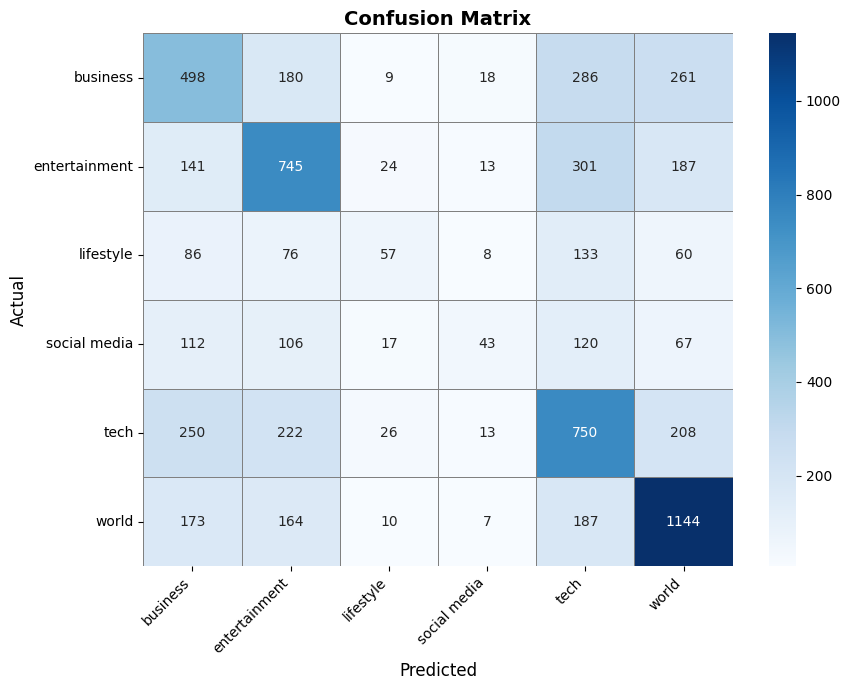

In [20]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    linewidths=0.5, linecolor='gray'
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 11 - Feature Importance

Checking which features the model found most useful for predicting the category.

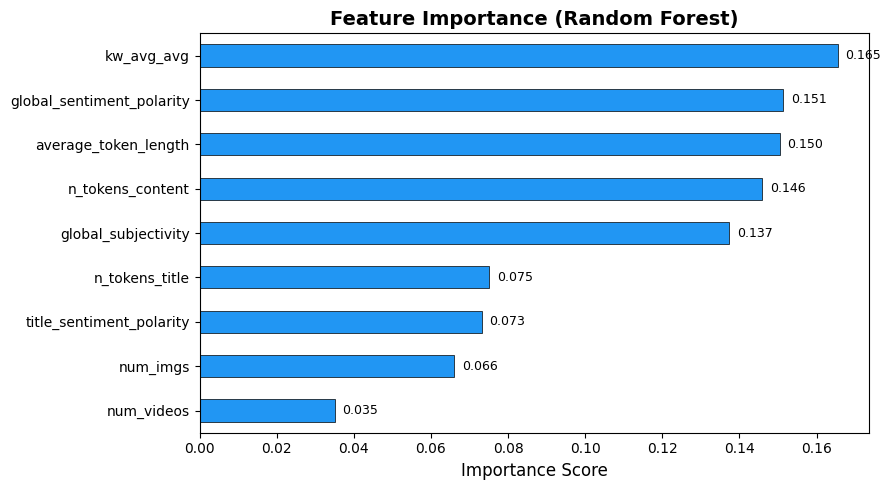

In [21]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
bars = feat_imp.plot(kind='barh', color='#2196F3', edgecolor='black', linewidth=0.5)
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)

# add value labels
for i, v in enumerate(feat_imp):
    plt.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [22]:
# feature importance table (sorted)
feat_table = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})
feat_table = feat_table.sort_values('Importance', ascending=False).reset_index(drop=True)
feat_table.index = feat_table.index + 1  # start index from 1
feat_table['Importance'] = feat_table['Importance'].round(4)
feat_table

,Feature,Importance
1,kw_avg_avg,0.1654
2,global_sentiment_polarity,0.1514
3,average_token_length,0.1505
4,n_tokens_content,0.1460
5,global_subjectivity,0.1373
6,n_tokens_title,0.0752
7,title_sentiment_polarity,0.0731
8,num_imgs,0.0661
9,num_videos,0.0351


## Step 12 - Sample Prediction

Testing the model with a sample article.

In [23]:
# creating a sample article with made-up values
sample_data = {
    'n_tokens_title': [12],
    'n_tokens_content': [800],
    'average_token_length': [4.7],
    'num_imgs': [5],
    'num_videos': [0],
    'kw_avg_avg': [3500],
    'global_sentiment_polarity': [0.12],
    'global_subjectivity': [0.48],
    'title_sentiment_polarity': [0.15]
}

sample_df = pd.DataFrame(sample_data)

# scale the sample
sample_scaled = scaler.transform(sample_df)

# predict
predicted_category = model.predict(sample_scaled)[0]
predicted_proba = model.predict_proba(sample_scaled)[0]

print('Sample Article Features:')
for col in sample_df.columns:
    print(f'  {col}: {sample_df[col].values[0]}')

print()
print('Predicted Category:', predicted_category)
print()
print('Prediction Probabilities:')
for cls, prob in zip(model.classes_, predicted_proba):
    bar = '#' * int(prob * 40)
    print(f'  {cls:15s} {prob:.3f} {bar}')

Sample Article Features:
  n_tokens_title: 12
  n_tokens_content: 800
  average_token_length: 4.7
  num_imgs: 5
  num_videos: 0
  kw_avg_avg: 3500
  global_sentiment_polarity: 0.12
  global_subjectivity: 0.48
  title_sentiment_polarity: 0.15

Predicted Category: tech

Prediction Probabilities:
  business        0.175 #######
  entertainment   0.185 #######
  lifestyle       0.115 ####
  social media    0.145 #####
  tech            0.265 ##########
  world           0.115 ####


## Summary

- Loaded the OnlineNewsPopularity dataset with 39,644 articles.
- Cleaned column names and created a target column from 6 binary channel columns.
- Removed articles with no category (kept around 32,000 rows).
- Selected 9 features related to content length, media, keywords, and sentiment.
- Split data 80/20 for training and testing.
- Applied StandardScaler for feature normalization.
- Trained a Random Forest model with 200 trees and balanced class weights.
- Evaluated using accuracy, classification report, and confusion matrix.
- Identified the most important features for category prediction.
- Demonstrated a sample prediction with probability scores.